In [2]:
import os, json
import numpy as np
import pandas as pd
from collections import defaultdict

def asegurar_bits(x, N):
    """
    Normaliza una solución binaria (bitstring) a un vector NumPy 0/1 de longitud N.

    Esta función se usa para unificar el formato de las soluciones provenientes de distintas fuentes:
    - Simulador adiabático / Ising (a veces devuelve arrays/listas de 0/1).
    - Dirac-3 / QCI (a veces devuelve un entero que codifica el bitstring).

    Params
    ----------
    x : int | list[int] | tuple[int] | np.ndarray
        Representación de la solución.
        - Si es lista/tupla/ndarray: se interpreta como vector binario explícito.
        - Si es int: se interpreta como un bitstring empaquetado en un entero (bits de x).

    N : int
        Número total de variables binarias (qubits) esperadas.
        Debe coincidir exactamente con el tamaño del vector resultante.

    Returns
    -------
    np.ndarray
        Vector 1D de longitud N con valores {0,1}, dtype=int.
        La convención para el caso entero es:
        - Se devuelve el bit más significativo primero (MSB → LSB), es decir,
          el primer elemento corresponde al bit de orden N-1 y el último al bit 0.
    """
    
    if isinstance(x, (list, tuple, np.ndarray)):
        arr = np.array(x, dtype=int).ravel()
        
        if arr.size != N:
            raise ValueError(f"Tamaño de bits {arr.size} != N ({N}).")
        return arr
        
    return np.array([(x >> k) & 1 for k in range(N-1, -1, -1)], dtype=int)

def energia_qubo(bits, lineal, cuadratica, desplazamiento=0.0):
    """
    Calcula la energía de un QUBO para un bitstring dado.

    Evalúa la expresión típica de un QUBO:
        E(x) = offset + sum_i (L_i * x_i) + sum_{i,j} (Q_{i,j} * x_i * x_j)
    donde:
        - x_i ∈ {0,1} son las variables binarias (qubits).
        - L_i son coeficientes lineales.
        - Q_{i,j} son coeficientes cuadráticos (acoplamientos).
        - offset (desplazamiento) es un término constante.

    Params
    ----------
    bits : array-like
        Vector binario (0/1) con la asignación de todas las variables del QUBO.
        Debe tener longitud al menos max(i,j)+1 para los índices presentes en 'lineal' y 'cuadratica'.

    lineal : dict[int, float]
        Diccionario de términos lineales. Clave = índice i, valor = coeficiente L_i.
        Ejemplo: {0: -1.2, 3: 0.5}

    cuadratica : dict[tuple[int,int], float]
        Diccionario de términos cuadráticos. Clave = (i,j), valor = coeficiente Q_{i,j}.
        Ejemplo: {(0,3): 2.0, (1,2): -0.7}
        
    desplazamiento : float, opcional
        Término constante (offset) que se suma a la energía. Por defecto 0.0.

    Returns
    -------
    float
        Energía total E(bits) evaluada sobre el bitstring.
    """
    
    e = float(desplazamiento)
    for i, a in lineal.items():
        e += a * bits[i]
        
    for (i, j), c in cuadratica.items():
        e += c * bits[i] * bits[j]
        
    return float(e)

def verificar_restricciones(bits, mapa_vars, n_posiciones, indices_depositos=0, n_ciudades=None, K_esperado=None):
    """
    Verifica restricciones de factibilidad sobre una solución binaria (bitstring) del MVRP codificado como QUBO.

    Esta función reconstruye la matriz one-hot X[i,t] (ciudad i en el slot/tiempo t) a partir del bitstring
    y del mapeo de variables `mapa_vars`. A partir de X calcula métricas de violación típicas del encoding.

    Params
    ----------
    bits : array-like
        Vector 0/1 que representa una solución candidata del QUBO. Se aplana a 1D.
        Debe tener longitud al menos igual al mayor índice de `mapa_vars` + 1.

    mapa_vars : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice del qubit/variable. Valor: (i, t).
        Ejemplo: {0: (0,0), 1: (1,0), 2: (0,1), ...}.

    n_posiciones : int
        Número total de slots/tiempos (T). Es el ancho de la matriz X[i,t].

    indices_depositos : int | list[int] | tuple[int] | set[int], opcional
        Índices de las ciudades que se consideran depósitos. Se normaliza internamente a un set de enteros.
        - Si se pasa un int, se interpreta como un único depósito.
        - Si se pasa colección, se interpreta como multi-depósito.

    n_ciudades : int, opcional
        Número total de ciudades. Si es None, se infiere a partir de `mapa_vars` (máximo i + 1).

    K_esperado : int | None, opcional
        Valor esperado de apariciones de depósitos (por ejemplo, K vehículos o nº de separadores en la secuencia).
        - Si es None: se fija K_esperado = K_encontrado y se pone viol_deposito = 0 (criterio informativo).
        - Si es un int: se valida contra K_encontrado.

    Returns
    -------
    dict
        Diccionario con:
        - "viol_pos"      : int, nº de slots que no cumplen one-hot.
        - "viol_una"      : int, nº de ciudades no-depósito que no aparecen exactamente una vez.
        - "viol_deposito" : int, 0/1 indicando si se cumple K_esperado (si se proporciona) o 0 si no se valida.
        - "K_encontrado"  : int, apariciones totales de depósitos en X.
        - "K_esperado"    : int, el K esperado usado en la comparación (o K_encontrado si no se proporcionó).
    """
    
    if n_ciudades is None:
        n_ciudades = max(i for (i, _t) in mapa_vars.values()) + 1

    bits = np.array(bits, dtype=int).ravel()

    # normalizar depósitos a set[int]
    if isinstance(indices_depositos, (set, list, tuple)):
        depot_set = set(int(x) for x in indices_depositos)
    else:
        depot_set = {int(indices_depositos)}

    X = np.zeros((n_ciudades, n_posiciones), dtype=int)
    for idx, (i, t) in mapa_vars.items():
        if idx < bits.size:
            X[i, t] = int(bits[idx])

    # 1 por posición
    por_posicion = np.sum(X, axis=0)
    viol_pos = int(np.sum(por_posicion != 1))

    # cada NO-depósito exactamente 1 vez
    por_ciudad = np.sum(X, axis=1)
    mascara_no_deposito = np.ones(n_ciudades, dtype=bool)
    
    for d in depot_set:
        if 0 <= d < n_ciudades:
            mascara_no_deposito[d] = False
    viol_una = int(np.sum(por_ciudad[mascara_no_deposito] != 1))

    # cuántas veces aparecen depósitos (multi-depósito)
    dep_list = [d for d in depot_set if 0 <= d < n_ciudades]
    K_encontrado = int(np.sum(X[dep_list, :])) if dep_list else 0

    # Segmento que evita resultdos de tipo 0/0 en k_encontrado/esperado
    if K_esperado is None:
        K_esperado = K_encontrado
        viol_deposito = 0
        
    else:
        K_esperado = int(K_esperado)
        if K_encontrado == K_esperado:
            viol_deposito = 0
        else:
            viol_deposito = 1

    return {
        "viol_pos": viol_pos,
        "viol_una": viol_una,
        "viol_deposito": viol_deposito,
        "K_encontrado": K_encontrado,
        "K_esperado": K_esperado
    }

def decodificar_ruta_multi(bits, mapa_vars, ciudades, n_posiciones, indices_depositos, circular=False):
    """
    Decodifica un bitstring del QUBO MVRP a:
      (1) una secuencia de ciudades por slot y
      (2) una lista de rutas segmentadas usando los depósitos como separadores.

    La codificación subyacente asume variables binarias x_{i,t} que indican si en el slot/tiempo t
    se elige la ciudad i. A partir de `bits` y `mapa_vars` se reconstruye una matriz X[i,t] y se
    obtiene la ciudad activa en cada slot tomando argmax por columna.

    Segmentación en rutas
    ---------------------
    Se considera que cada vez que aparece un depósito en la secuencia, se "cierra" la ruta actual
    y comienza una nueva. En concreto:
      - Los depósitos actúan como separadores.
      - Los clientes (no depósitos) se agregan a la ruta actual.
      - Si hay depósitos consecutivos, la ruta intermedia queda vacía y NO se añade (por diseño),
        ya que solo se añade una ruta si contiene al menos un cliente.

    Modos de funcionamiento
    -----------------------
    circular = False (abierto):
        Interpreta la secuencia como lineal de longitud n_posiciones.
        Ejemplo: D -> A -> B -> D -> C  (rutas: [D:A-B], [D:C])

    circular = True (circular/anillo):
        Interpreta la secuencia como un ciclo.
        - Primero rota la secuencia para empezar en el primer depósito encontrado (si existe).
        - Luego añade el primer elemento al final para "cerrar" el ciclo.
        Nota: la secuencia devuelta tiene longitud n_posiciones + 1 en este modo.

    Params
    ----------
    bits : array-like
        Vector binario 0/1 (o equivalente) con la solución del QUBO. Se aplana a 1D.
        Si hay violaciones one-hot, argmax elige la ciudad con mayor activación en cada slot.

    mapa_vars : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice del qubit/variable. Valor: (i, t).

    ciudades : list[str]
        Lista con los nombres de todas las ciudades (depósitos primero o mezclados según tu construcción).
        Se usa para convertir índices a nombres legibles.

    n_posiciones : int
        Número total de slots/tiempos (T) de la codificación.

    indices_depositos : int | list[int] | tuple[int] | set[int]
        Índices de las ciudades que se consideran depósitos. Se normaliza internamente a set[int].

    circular : bool, opcional
        - False: secuencia abierta (lineal).
        - True : secuencia circular (rota y cierra el anillo).
        Por defecto False.

    Return
    -------
    tuple[list[str], list[tuple[str, list[str]]]]
        - secuencia_nombres: lista con la ciudad elegida en cada slot (en modo circular, incluye el cierre).
        - rutas: lista de tuplas (deposito_inicio, [clientes...]) para cada segmento no vacío.
    """
    
    n_ciudades = len(ciudades)
    bits = np.array(bits, dtype=int).ravel()

    # normalizar depósitos a set[int]
    if isinstance(indices_depositos, (set, list, tuple)):
        depot_set = set(int(x) for x in indices_depositos)
    else:
        depot_set = {int(indices_depositos)}

    X = np.zeros((n_ciudades, n_posiciones), dtype=int)
    for idx, (i, t) in mapa_vars.items():
        if idx < bits.size:
            X[i, t] = int(bits[idx])

    secuencia_indices = []
    for t in range(n_posiciones):
        secuencia_indices.append(int(np.argmax(X[:, t])))

    # --- modo circular: rotar a primer depósito y cerrar el anillo ---
    if circular:
        try:
            start_idx = next(k for k, x in enumerate(secuencia_indices) if x in depot_set)
        except StopIteration:
            start_idx = 0
        ring = secuencia_indices[start_idx:] + secuencia_indices[:start_idx]
        ring = ring + [ring[0]]  # cerrar
        secuencia_indices = ring  # longitud = n_posiciones + 1

    secuencia_nombres = [ciudades[i] for i in secuencia_indices]

    rutas = []
    actual = []

    # depósito inicial
    deposito_inicio_actual = None
    try:
        deposito_inicio_actual = next(i for i in secuencia_indices if i in depot_set)
    except StopIteration:
        deposito_inicio_actual = secuencia_indices[0]

    deposito_inicio_actual_nombre = ciudades[deposito_inicio_actual]

    # iteración
    for idx_ciudad in secuencia_indices[1:]:
        nombre_ciudad = ciudades[idx_ciudad]
        if idx_ciudad in depot_set:
            if actual:
                rutas.append((deposito_inicio_actual_nombre, actual))
            actual = []
            deposito_inicio_actual_nombre = nombre_ciudad
        else:
            actual.append(nombre_ciudad)

    if actual:
        rutas.append((deposito_inicio_actual_nombre, actual))

    return secuencia_nombres, rutas

def evaluar_bits(bits, lineal, cuadratica, desplazamiento, mapa_vars, ciudades, n_posiciones, costes,
                origenes_indx, circular=False, K_esperado=None):
    """
    Evalúa un bitstring candidato del QUBO MVRP y devuelve métricas comparables entre solvers.
    Puente entre la solución binaria (bitstring) producida por Dirac-3 / QCI / simulador adiabático,
    y las magnitudes en el notebook (energía QUBO, coste real, violaciones, rutas).

    Params
    ----------
    bits : array-like
        Vector binario (0/1) que representa la solución candidata. Se aplana a 1D.
        Puede provenir directamente del solver (lista/ndarray) o de conversiones previas.

    lineal : dict[int, float]
        Coeficientes lineales del QUBO (términos x_i).

    cuadratica : dict[tuple[int,int], float]
        Coeficientes cuadráticos del QUBO (términos x_i x_j).

    desplazamiento : float
        Offset constante del QUBO (a veces llamado "offset" o "bias global").

    mapa_vars : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice de qubit/variable.
        Valor: (i, t) con i índice de ciudad y t índice de slot/tiempo.

    ciudades : list[str]
        Lista con nombres de ciudades (para decodificación y salida legible).

    n_posiciones : int
        Número total de slots/tiempos de la codificación (T).

    costes : np.ndarray
        Matriz de costes/distancias entre ciudades, shape = (n_ciudades, n_ciudades).
        Se usa para calcular el coste real de la ruta reconstruida.

    origenes_indx : int | list[int] | tuple[int] | set[int]
        Índices de las ciudades que se consideran depósitos.
        Se pasa a `verificar_restricciones` y a `decodificar_ruta_multi`.

    circular : bool, opcional
        Controla si el cálculo de coste real y la decodificación se interpretan como:
        - False (por defecto): recorrido abierto, suma transiciones t->t+1 hasta el último slot.
        - True : recorrido circular, incluye también la transición último->primero.

    K_esperado : int | None, opcional
        Número esperado de apariciones de depósitos (según tu definición de K en el encoding).
        Si se proporciona, `verificar_restricciones` marca violación si K_encontrado != K_esperado.
        Si es None, la comprobación de K queda como informativa (no penaliza)

    Returns
    -------
    dict
        Diccionario con métricas:
        - "energia_qubo"   : float, energía del QUBO evaluada sobre el bitstring.
        - "coste_real"     : float, distancia total reconstruida desde la secuencia (abierta o circular).
        - "viol_pos"       : int, nº de slots que no cumplen one-hot.
        - "viol_una"       : int, nº de destinos que no aparecen exactamente una vez.
        - "viol_deposito"  : int, 0/1 por incumplimiento de K esperado (si aplica).
        - "K_encontrado"   : int, apariciones de depósitos en el bitstring.
        - "K_esperado"     : int, K usado en la comparación.
        - "secuencia"      : list[str], secuencia de ciudades por slot (en circular, incluye cierre).
        - "rutas"          : list[tuple[str, list[str]]], rutas segmentadas por depósitos.
    """
    
    bits = np.array(bits, dtype=int).ravel()
    e_qubo = energia_qubo(bits, lineal, cuadratica, desplazamiento)

    cons = verificar_restricciones(
        bits, mapa_vars, n_posiciones,
        indices_depositos=origenes_indx,
        n_ciudades=len(ciudades),
        K_esperado=K_esperado
    )

    secuencia, rutas = decodificar_ruta_multi(
        bits, mapa_vars, ciudades, n_posiciones,
        indices_depositos=origenes_indx,
        circular=circular
    )

    indices_por_pos = []
    for t in range(n_posiciones):
        candidatos = [i for (idx, (i, tt)) in mapa_vars.items() if tt == t and bits[idx] == 1]
        if candidatos:
            i = candidatos[0]
        else:
            pares_slot = [(k, ii) for (k, (ii, tt2)) in mapa_vars.items() if tt2 == t]
            i = max(pares_slot, key=lambda kv: bits[kv[0]])[1]
        indices_por_pos.append(i)

    # coste real abierto o circular
    coste_real = 0.0
    T = n_posiciones if circular else (n_posiciones - 1)
    for t in range(T):
        i = indices_por_pos[t]
        j = indices_por_pos[(t + 1) % n_posiciones] if circular else indices_por_pos[t + 1]
        if i != j:
            coste_real += float(costes[i, j])

    return {
        "energia_qubo": float(e_qubo),
        "coste_real": float(coste_real),
        "viol_pos": cons["viol_pos"],
        "viol_una": cons["viol_una"],
        "viol_deposito": cons["viol_deposito"],
        "K_encontrado": cons["K_encontrado"],
        "K_esperado": cons["K_esperado"],
        "secuencia": secuencia,
        "rutas": rutas
    }

def comparar_qci_vs_simulacion(soluciones, energias, lineal, cuadratica, desplazamiento, mapa_vars, ciudades, n_posiciones, costes, indices_depositos=0, bits_simulacion=None, top_k=10, circular=False, K_esperado=None):
    """
    Construye una tabla comparativa (DataFrame) entre resultados de Dirac-3/QCI y el simulador adiabático.

    La función recibe un conjunto de soluciones (bitstrings) y energías devueltas por Dirac-3,
    evalúa cada solución sobre el QUBO original (energía QUBO + restricciones + coste real + decodificación),
    y ordena las mejores soluciones según:
        1) factibilidad (menos violaciones primero)
        2) energía QUBO
        3) coste real

     Params
    ----------
    soluciones : list[int] | list[array-like]
        Lista de soluciones devueltas por Dirac/QCI.
        Cada elemento puede ser:
          - un entero que codifica el bitstring, o
          - una lista/ndarray de 0/1.
        Se normaliza a vector binario mediante `asegurar_bits`.

    energias : list[float]
        Energías asociadas a cada elemento de `soluciones` tal como las reporta la API (energía del solver).

    lineal : dict[int, float]
        Coeficientes lineales del QUBO.

    cuadratica : dict[tuple[int,int], float]
        Coeficientes cuadráticos del QUBO.

    desplazamiento : float
        Offset constante del QUBO.

    mapa_vars : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice de qubit/variable. Valor: (i, t).

    ciudades : list[str]
        Nombres de ciudades (para decodificación legible).

    n_posiciones : int
        Número de slots/tiempos (T).

    costes : np.ndarray
        Matriz de costes/distancias entre ciudades para calcular `coste_real`.

    indices_depositos : int | list[int] | tuple[int] | set[int], opcional
        Índices de depósitos en la lista de ciudades. Se pasa a `evaluar_bits`.

    bits_simulacion : array-like | None, opcional
        Bitstring 0/1 obtenido por el simulador adiabático (o por otra heurística).
        Si se proporciona, se evalúa con `evaluar_bits` y se añade como fila adicional con índice "SIMULACION".
        Si es None, no se añade esa fila.

    top_k : int, opcional
        Número de soluciones de Dirac/QCI que se muestran tras ordenar y recortar la tabla. Por defecto 10.

    circular : bool, opcional
        Controla el modo de evaluación/decodificación (abierto vs circular) pasado a `evaluar_bits`.
        Debe ser consistente con el QUBO que se construyó:
          - False: coste real suma t->t+1 hasta el último slot.
          - True : incluye también el cierre último->primero.

    K_esperado : int | None, opcional
        Valor esperado de apariciones totales de depósitos (según tu encoding).
        Si se proporciona, afecta a `viol_deposito` a través de `verificar_restricciones`.
        Si es None, el chequeo de K queda informativo sin penalización.

    Returns
    -------
    pandas.DataFrame
        DataFrame con columnas:
          - energia_api            : energía devuelta por la API (float) o None en la fila de simulación.
          - energia_qubo           : energía del QUBO evaluada localmente.
          - coste_real             : coste/ruta reconstruido.
          - viol_pos, viol_una,
            viol_deposito          : métricas de violación.
          - K_encontrado/esperado  : string "K_encontrado/K_esperado".
          - secuencia              : secuencia (truncada) de ciudades.
          - rutas                  : rutas segmentadas por depósitos.

        Si `bits_simulacion` se proporciona, se añade una última fila con índice "SIMULACION".
    """
        
    filas = []
    for s, e in zip(soluciones, energias):
        b = asegurar_bits(s, len(mapa_vars))
        ev = evaluar_bits(b, lineal, cuadratica, desplazamiento, mapa_vars, ciudades, n_posiciones, costes, indices_depositos, circular=circular, K_esperado=K_esperado)
        filas.append({
            "energia_api": float(e),
            "energia_qubo": ev["energia_qubo"],
            "coste_real": ev["coste_real"],
            "viol_pos": ev["viol_pos"],
            "viol_una": ev["viol_una"],
            "viol_deposito": ev["viol_deposito"],
            "K_encontrado/esperado": f'{ev["K_encontrado"]}/{ev["K_esperado"]}',
            "secuencia": " → ".join(simple_str(ev["secuencia"])[:min(20, len(simple_str(ev["secuencia"]))) ]),
            "rutas": " | ".join("-".join(simple_str(t)) for t in ev["rutas"])
        })
    df = pd.DataFrame(filas)
    if not df.empty:
        df = df.sort_values(by=["viol_pos", "viol_una", "viol_deposito", "energia_qubo", "coste_real"]).head(top_k).reset_index(drop=True)
    if bits_simulacion is not None:
        evs = evaluar_bits(bits_simulacion, lineal, cuadratica, desplazamiento, mapa_vars, 
                       ciudades, n_posiciones, costes, indices_depositos, circular=circular, K_esperado=K_esperado)
        fila_sim = {
            "energia_api": None,
            "energia_qubo": evs["energia_qubo"],
            "coste_real": evs["coste_real"],
            "viol_pos": evs["viol_pos"],
            "viol_una": evs["viol_una"],
            "viol_deposito": evs["viol_deposito"],
            "K_encontrado/esperado": f'{evs["K_encontrado"]}/{evs["K_esperado"]}',
            "secuencia": " → ".join(simple_str(evs["secuencia"])[:min(20, len(simple_str(evs["secuencia"]))) ]),
            "rutas": " | ".join("-".join(simple_str(t)) for t in evs["rutas"])
        }
        df_sim = pd.DataFrame([fila_sim])
        df_sim.index = ["SIMULACION"]
        df = pd.concat([df, df_sim])
    return df

def qubo_a_archivo_polinomio(lineal, cuadratica, N, nombre_archivo):
    """
    Construye el diccionario JSON (formato "polynomial") que Dirac-3 espera para cargar un QUBO.

    Dirac-3 (QCI) permite describir un problema como un polinomio (aquí de grado 2: QUBO) mediante una lista
    de términos, donde cada término se codifica con:
      - "idx": lista de índices de variables implicadas
      - "val": coeficiente del término

    En este notebook se usa la convención habitual de Dirac-3:
      - Las variables se indexan desde 1.
      - El índice 0 se reserva como "constante" (término independiente) en algunos formatos.
        Para términos lineales se usa el par [0, var] para indicar 0*var (es decir, un término de grado 1).

    Params
    ----------
    lineal : dict[int, float]
        Coeficientes lineales del QUBO. Clave = índice i (0-based local), valor = a_i.

    cuadratica : dict[tuple[int,int], float]
        Coeficientes cuadráticos del QUBO. Clave = (i,j) (0-based local), valor = b_ij.
        Nota: Si tu QUBO guarda ambos (i,j) y (j,i), esta función los suma en un único término.

    N : int
        Número total de variables binarias del QUBO (qubits). Dirac lo espera como "num_variables".

    nombre_archivo : str
        Nombre del archivo lógico que se incluye en el JSON (no necesariamente un path en disco).
        Dirac lo usa como identificador interno del input.

    Returns
    -------
    dict
        Diccionario en formato "polynomial" listo para serializar a JSON y enviar a Dirac-3.
    """
    
    datos = []
    for i, a in lineal.items():
        a = float(a)
        if a != 0.0:
            datos.append({"idx": [0, int(i) + 1], "val": a})
    acumulados = defaultdict(float)
    for (i, j), b in cuadratica.items():
        ii, jj = int(i) + 1, int(j) + 1
        if ii > jj:
            ii, jj = jj, ii
        acumulados[(ii, jj)] += float(b)
    for (ii, jj), b in acumulados.items():
        if b != 0.0:
            datos.append({"idx": [ii, jj], "val": b})
    archivo = {
        "file_name": nombre_archivo,
        "file_config": {
            "polynomial": {
                "num_variables": int(N),
                "min_degree": 1,
                "max_degree": 2,
                "data": datos
            }
        }
    }
    return archivo

def simple_str(x):
    """
    Convierte una estructura anidada (listas/tuplas) en una lista plana de strings.

    Esta función se usa como utilidad de "formateo robusto" para imprimir resultados en tablas
    o concatenar secuencias/rutas sin preocuparnos de si los elementos vienen anidados.

    Comportamiento
    --------------
    - Si `x` es un valor "atómico" (no lista/tupla), devuelve una lista con `str(x)`.
    - Si `x` es una lista o tupla (posiblemente anidada), recorre recursivamente todos sus elementos
      y devuelve una lista plana con `str(elemento)` para cada elemento atómico encontrado.
    - El orden de salida respeta el recorrido en profundidad (depth-first) de izquierda a derecha.

    Params
    ----------
    x : cualquiera
        Objeto a convertir. Puede ser un escalar, string, número, o una estructura anidada
        compuesta de listas/tuplas.

    Returns
    -------
    list[str]
        Lista plana de strings.
    """
    
    out = []
    def rec(y):
        if isinstance(y, (list, tuple)):
            for z in y:
                rec(z)
        else:
            out.append(str(y))
    rec(x)
    return out

In [3]:
from qci_client import QciClient
from dotenv import load_dotenv

load_dotenv() 

client = QciClient(url=os.environ.get("QCI_API"), api_token=os.environ.get("QCI_TOKEN"))
print(client.get_allocations())

{'allocations': {'csample': {'metered': True, 'seconds': 0, 'paid': False}, 'dirac': {'metered': True, 'seconds': 260, 'paid': True}}}


In [15]:
import json, numpy as np

qubo_json = "capturas/mvrp_qubo_MismoDepositoA.json"
qubo_npz  = "capturas/mvrp_qubo_MismoDepositoA.npz"

with open(qubo_json) as f:
    qubo = json.load(f)
    costes = np.load(qubo_npz)["costes"]

linear = {int(k): float(v) for k, v in qubo["linear"].items()}
quadratic = {}
for k, v in qubo["quadratic"].items():
    i, j = map(int, k.split(","))
    quadratic[(i, j)] = float(v)

N = int(qubo["N"])
ciudades = qubo["ciudades"]
n_slots = int(qubo["n_slots"])
origenes_indx = set(int(x) for x in qubo.get("origenes_indx", []))
varmap = {int(k): tuple(v) for k, v in qubo["varmap"].items()}
offset = float(qubo["offset"])

In [25]:
poly_file = qubo_a_archivo_polinomio(linear, quadratic, N, nombre_archivo="mvrp_qubo_dirac3")
file_resp = client.upload_file(file=poly_file)         

job_body = client.build_job_body(
    job_type="sample-hamiltonian-integer",             
    job_params={
        "device_type": "dirac-3",
        "num_levels": [2]*N,                        
        "num_samples": 50,
    },
    polynomial_file_id=file_resp["file_id"],
    job_name="mvrp_qubo_dirac3",
)

results = resp.get("results") or resp.get("job_info", {}).get("job_result", {}) or {}
solutions = results.get("solutions") or results.get("samples") or []
print("STATUS:", resp.get("status"), "| #sols:", len(solutions))

STATUS: COMPLETED | #sols: 15


In [5]:
import json
from pathlib import Path
from datetime import datetime

out_dir = Path("dirac3")
out_dir.mkdir(exist_ok=True)

filename = out_dir / f"resp_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

with open(filename, "w", encoding="utf-8") as f:
    json.dump(resp, f, ensure_ascii=False, indent=2)

print("Guardado:", filename)


NameError: name 'resp' is not defined

In [26]:
import json
import pandas as pd
from pathlib import Path

resp_file = Path("dirac3/resp_MismoDepositoA.json")

with open(resp_file, "r", encoding="utf-8") as f:
    resp = json.load(f)

results = resp.get("results") or resp.get("job_info", {}).get("job_result", {}) or {}
solutions = results.get("solutions") or results.get("samples") or []
energies  = results.get("energies")  or results.get("values")  or []
counts    = results.get("counts")
K         = results.get("k")
df = comparar_qci_vs_simulacion(solutions, energies,linear, quadratic, offset, varmap, ciudades, n_slots, costes, origenes_indx, bits_simulacion=globals().get("sim_bits"))

pd.set_option("display.max_colwidth", 160)
df

,energia_api,energia_qubo,coste_real,viol_pos,viol_una,viol_deposito,K_encontrado/esperado,secuencia,rutas
0,-81.0,4.0,4.0,0,0,0,2/2,Pallet Town → Pewter City → Pallet Town,Pallet Town-Pewter City
1,-79.0,6.0,6.0,0,0,0,2/2,Celadon City → Pewter City → Celadon City,Celadon City-Pewter City
2,-59.0,26.0,6.0,0,0,0,2/2,Pewter City → Celadon City → Pallet Town,
3,-65.0,20.0,2.0,1,0,0,3/3,Fuschia City → Celadon City → Fuschia City,
4,-65.0,20.0,2.0,1,0,0,3/3,Fuschia City → Celadon City → Fuschia City,
5,-64.0,21.0,2.0,1,0,0,3/3,Celadon City → Fuschia City → Celadon City,
6,-64.0,21.0,2.0,1,0,0,3/3,Celadon City → Fuschia City → Celadon City,
7,-64.0,21.0,4.0,1,0,0,3/3,Fuschia City → Pallet Town → Fuschia City,
8,-64.0,21.0,4.0,1,0,0,3/3,Fuschia City → Pallet Town → Fuschia City,
9,-62.0,23.0,4.0,1,0,0,3/3,Pallet Town → Fuschia City → Pallet Town,


In [27]:
import numpy as np
import matplotlib.pyplot as plt

def pesos_por_counts(counts, n):
    """
    Construye un vector de pesos normalizados (probabilidades) a partir de `counts`.

    En muchos solvers (p.ej. Dirac-3/QCI), además de una lista de soluciones se devuelve
    un array `counts` que indica cuántas veces apareció cada solución en el muestreo.
    Esta función convierte esos conteos en pesos que suman 1 para poder:
      - calcular medias ponderadas,
      - construir mapas de calor (ocupación por slot),
      - estimar matrices de transición,
      - o representar distribuciones donde las soluciones más frecuentes pesen más.

    Params
    ----------
    counts : list[float|int] | np.ndarray | None
        Conteos/frecuencias asociados a las soluciones en el mismo orden.
        - Si es None o está vacío, se asume peso uniforme.
        - Si tiene menos de `n` elementos, se rellena con 1.0 para evitar errores de tamaño.

    n : int
        Número de soluciones que se van a ponderar (normalmente `len(solutions)` o un top-k).

    Returns
    -------
    np.ndarray
        Vector 1D de longitud `n` con pesos >= 0 que suman 1.
        Si la suma de los conteos es 0 (caso degenerado), devuelve pesos uniformes.
    """
    
    if counts is None or len(counts) == 0:
        w = np.ones(n, dtype=float)
    else:
        w = np.array(counts[:n], dtype=float)
        if w.size < n:
            w = np.pad(w, (0, n - w.size), constant_values=1.0)
    w = np.clip(w, 0, None)
    s = w.sum()

    if s > 0:
        return w / s 
    else:
        return np.ones(n)/n

def solucion_posible(df):
    """
    Devuelve una máscara booleana que indica qué filas del DataFrame corresponden a soluciones factibles.

    Params
    ----------
    df : pandas.DataFrame
        DataFrame devuelto por `comparar_qci_vs_simulacion` (u otro con las mismas columnas),
        que debe contener al menos las columnas: "viol_pos", "viol_una", "viol_deposito".

    Returns
    -------
    pandas.Series (bool)
        Serie booleana indexada igual que `df`, con True para las soluciones factibles y False para las no factibles.
    """
    
    return (df["viol_pos"]==0) & (df["viol_una"]==0) & (df["viol_deposito"]==0)

def filtrar_soluciones_factibles(solutions, counts,
                                lineal, cuadratica, desplazamiento,
                                varmap, ciudades, n_slots, costes,
                                indices_depositos=0, circular=False, K_esperado=None,
                                max_solutions=None):
    """
    Filtra las muestras del solver y devuelve únicamente las soluciones factibles (y sus counts).

    ParMA
    ----------
    solutions : list[int] | list[array-like]
        Lista de soluciones producidas por el solver (Dirac-3/QCI, etc.).
        Cada elemento puede ser:
          - un entero que codifica el bitstring, o
          - un vector/lista/ndarray de 0/1.
        Se normaliza a vector binario con `asegurar_bits`.

    counts : list[int|float] | np.ndarray | None
        Frecuencias asociadas a cada solución en el mismo orden.
        - Si counts es None o vacío, se asume 1 para todas las soluciones (pesos uniformes).
        - Si tiene menos elementos que solutions, solo se filtrará hasta donde llegue `zip`.

    lineal, cuadratica, desplazamiento :
        Componentes del QUBO usados por `evaluar_bits` (energía + restricciones).

    varmap : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Se usa para decodificación y verificación de restricciones.

    ciudades : list[str]
        Nombres de ciudades (solo se usa dentro de `evaluar_bits` para decodificar/medir coste).

    n_slots : int
        Número total de slots/posiciones del encoding.

    costes : np.ndarray
        Matriz de costes/distancias entre ciudades para calcular el coste real dentro de `evaluar_bits`.

    indices_depositos : int | list[int] | tuple[int] | set[int], opcional
        Índices de depósitos. Se pasa a `evaluar_bits` como `indices_depositos`.

    circular : bool, opcional
        Indica si la evaluación/decodificación se interpreta como secuencia abierta o circular.
        Debe ser consistente con el QUBO que estás evaluando.

    K_esperado : int | None, opcional
        Valor esperado de apariciones de depósitos (según tu definición de K).
        - Si es None, `viol_deposito` no penaliza (criterio informativo).
        - Si es int, se exige K_encontrado == K_esperado para factibilidad completa.

    max_solutions : int | None, opcional
        Si se especifica, corta el filtrado cuando ya se han encontrado `max_solutions` soluciones factibles.
        Útil para acelerar cuando tienes muchas muestras.


    Returns
    -------
    tuple[list, list]
        (solutions_f, counts_f)
        - solutions_f: lista de soluciones factibles (mismo formato que el input: int o vector).
        - counts_f   : lista de counts alineada con solutions_f.
    """
    if counts is None or len(counts) == 0:
        counts_iter = [1] * len(solutions)
    else:
        counts_iter = list(counts)

    sol_f, cnt_f = [], []
    for s, c in zip(solutions, counts_iter):
        b = asegurar_bits(s, len(varmap))
        ev = evaluar_bits(b, lineal, cuadratica, desplazamiento,
                          varmap, ciudades, n_slots, costes,
                          indices_depositos, circular=circular, K_esperado=K_esperado)
        if (ev["viol_pos"] == 0) and (ev["viol_una"] == 0) and (ev["viol_deposito"] == 0):
            sol_f.append(s)
            cnt_f.append(c)
            if max_solutions is not None and len(sol_f) >= max_solutions:
                break

    return sol_f, cnt_f

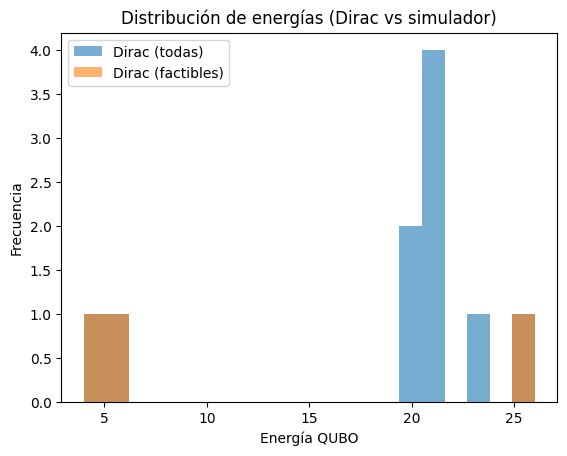

In [28]:
posible = solucion_posible(df)

if "SIMULACION" in df.index:
    columna_sim = df.loc[df.index=="SIMULACION"]
else:
    columna_sim = None

vals_all = df.loc[df.index!="SIMULACION", "energia_qubo"].values
vals_posible = df.loc[(df.index!="SIMULACION") & posible, "energia_qubo"].values

plt.figure()
plt.hist(vals_all, bins=20, alpha=0.6, label="Dirac (todas)")
plt.hist(vals_posible, bins=20, alpha=0.6, label="Dirac (factibles)")

if columna_sim is not None and len(columna_sim) > 0:
    e_sim = float(columna_sim["energia_qubo"].iloc[0])
    plt.axvline(e_sim, linestyle="--", label="Simulador (energia_qubo)")

plt.xlabel("Energía QUBO")
plt.ylabel("Frecuencia")
plt.legend()
plt.title("Distribución de energías (Dirac vs simulador)")
plt.show()


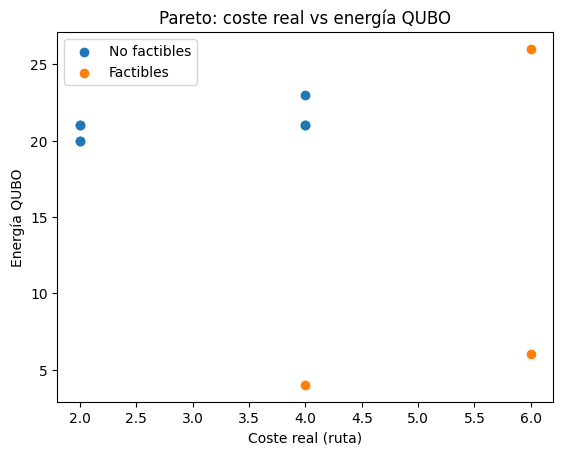

In [29]:
plt.figure()
mask = df.index != "SIMULACION"

x = df.loc[mask, "coste_real"].values
y = df.loc[mask, "energia_qubo"].values

plt.scatter(x[~posible[mask].values], y[~posible[mask].values], label="No factibles")
plt.scatter(x[ posible[mask].values], y[ posible[mask].values], label="Factibles")

# punto simulación si existe
if "SIMULACION" in df.index:
    plt.scatter([df.loc["SIMULACION","coste_real"]], [df.loc["SIMULACION","energia_qubo"]], marker="x", label="SIMULACION")

plt.xlabel("Coste real (ruta)")
plt.ylabel("Energía QUBO")
plt.legend()
plt.title("Pareto: coste real vs energía QUBO")
plt.show()

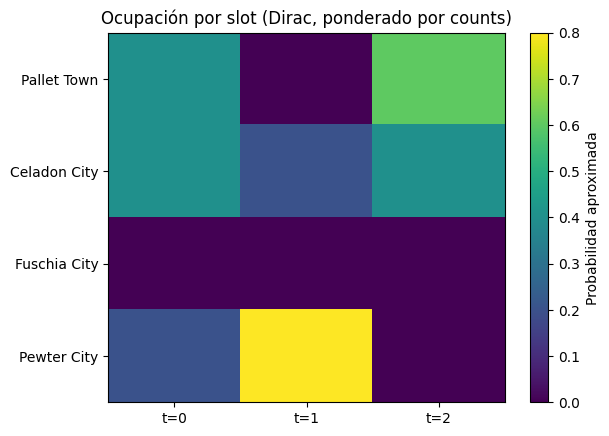

In [31]:
solutions_f, counts_f = filtrar_soluciones_factibles(
    solutions, counts,
    linear, quadratic, offset,
    varmap, ciudades, n_slots, costes,
    indices_depositos=origenes_indx,
    circular=False,
    K_esperado=K
)

def heatmap_ocupacion(solutions, counts, varmap, n_ciudades, n_slots):

    """
    Calcula un mapa de calor de ocupación marginal P(x_{i,t}=1) a partir de muestras del solver.
    NO reconstruye rutas completas, sino la ocupación marginal de cada variable a lo largo
    del muestreo.

    Params
    ----------
    solutions : list[int] | list[array-like]
        Lista de soluciones devueltas por el solver.
        Cada elemento puede ser:
          - un entero que codifica el bitstring, o
          - una lista/ndarray de 0/1.
        Se normaliza con `asegurar_bits`.

    counts : list[int|float] | np.ndarray | None
        Frecuencias asociadas a cada solución en el mismo orden. Si es None o está vacío,
        se asume peso uniforme (todas las soluciones pesan igual).
        Se convierten a pesos normalizados con `pesos_por_counts`.

    varmap : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice de qubit/variable.
        Valor: (i, t), donde i es índice de ciudad y t índice de slot.

    n_ciudades : int
        Número total de ciudades (alto del mapa).

    n_slots : int
        Número total de slots/tiempos (ancho del mapa).

     Retorna
    -------
    np.ndarray
        Matriz `occ` de shape (n_ciudades, n_slots) con valores en [0,1] (aprox).
        Nota: si `pesos_por_counts` normaliza a suma 1, `occ` queda naturalmente normalizada.
    """
    W = pesos_por_counts(counts, len(solutions))
    occ = np.zeros((n_ciudades, n_slots), dtype=float)
    for s, w in zip(solutions, W):
        b = asegurar_bits(s, len(varmap))
        for q, (i,t) in varmap.items():
            if q < b.size:
                occ[i,t] += w * b[q]
    return occ

occ = heatmap_ocupacion(solutions_f, counts_f, varmap, len(ciudades), n_slots)

plt.figure()
plt.imshow(occ, aspect="auto")
plt.yticks(range(len(ciudades)), ciudades)
plt.xticks(range(n_slots), [f"t={t}" for t in range(n_slots)])
plt.colorbar(label="Probabilidad aproximada")
plt.title("Ocupación por slot (Dirac, ponderado por counts)")
plt.show()


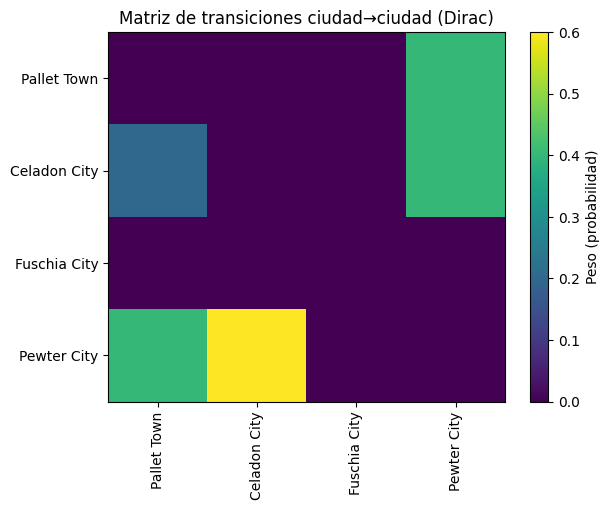

In [32]:
def heatmap_transiciones(solutions, counts, varmap, n_ciudades, n_slots, circular=False):

    """
    Estima una matriz de transiciones ciudad→ciudad a partir de muestras (bitstrings) del solver.

    La idea es construir una matriz T de tamaño (n_ciudades, n_ciudades) tal que:
        T[a,b] ≈ "peso" (probabilidad) de observar la transición a → b
    cuando se recorre la secuencia decodificada por slots (tiempos) de cada muestra.

    Params
    ----------
    solutions : list[int] | list[array-like]
        Lista de soluciones del solver (cada una puede ser entero codificado o vector 0/1).
        Se normaliza con `asegurar_bits`.

    counts : list[int|float] | np.ndarray | None
        Frecuencias asociadas a cada solución en el mismo orden (opcional).
        Se convierte a pesos con `pesos_por_counts`.

    varmap : dict[int, tuple[int,int]]
        Mapeo variable->(ciudad, slot). Clave: índice de qubit/variable. Valor: (i,t).

    n_ciudades : int
        Número total de ciudades.

    n_slots : int
        Número total de slots/tiempos.

    circular : bool, opcional
        - False: secuencia abierta (no se cierra).
        - True : secuencia circular (incluye transición último→primero).
        Debe ser consistente con cómo se construyó/evalúa el QUBO.

    Returns
    -------
    np.ndarray
        Matriz T de shape (n_ciudades, n_ciudades) con pesos acumulados.
        Si `counts` está normalizado por `pesos_por_counts`, T suele sumar ≈ número de transiciones
        ponderadas (no necesariamente 1). Se interpreta de forma relativa (más alto = más probable).
    """
    W = pesos_por_counts(counts, len(solutions))
    T = np.zeros((n_ciudades, n_ciudades), dtype=float)

    # Precomputar variables por slot para acelerar la decodificación
    vars_by_t = [[] for _ in range(n_slots)]
    for q,(i,t) in varmap.items():
        vars_by_t[t].append((q,i))

    for s, w in zip(solutions, W):
        b = asegurar_bits(s, len(varmap))

        # Decodificar secuencia por slot mediante argmax robusto
        seq = []
        for t in range(n_slots):
            cand = [(b[q], i) for q,i in vars_by_t[t] if q < b.size]
            i_t = max(cand, key=lambda x: x[0])[1]  # argmax
            seq.append(i_t)
        L = n_slots if circular else (n_slots-1)
        for t in range(L):
            a = seq[t]
            b2 = seq[(t+1)%n_slots] if circular else seq[t+1]
            if a != b2:
                T[a,b2] += w
    return T

ht = heatmap_transiciones(solutions_f, counts_f, varmap, len(ciudades), n_slots, circular=False)

plt.figure()
plt.imshow(ht, aspect="auto")
plt.xticks(range(len(ciudades)), ciudades, rotation=90)
plt.yticks(range(len(ciudades)), ciudades)
plt.colorbar(label="Peso (probabilidad)")
plt.title("Matriz de transiciones ciudad→ciudad (Dirac)")
plt.show()
